In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Подгружаем наш файл с данными по трекам
df = pd.read_csv("spotify_artist_streaming_2020_2025.csv")


In [9]:
# (первые 10 строк)
print("Первые 10 строк:")
display(df.head(10))

# проверяем размер
print(f"Размер таблицы: {df.shape}")

# список колонок
print(f"Колонки: {df.columns.tolist()}")

# типы данных и пропуски
df.info()


Первые 10 строк:


,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,...,popularity_category,loudness_category,key_name,mode_name,is_explicit_bool,release_quarter,is_weekend_release,log_stream_count,upbeat_score,artist_track_count
0,346d85e2-ffde-41b3-854a-589ed880b91f,Storm,Ethereal,The Hollow Journeys,2021-10-06,Pop,169594,47,0.6777,0.7949,...,Medium,Loud,A,Major,False,Q4,False,10.7492,0.6632,3232
1,12bc268a-363b-4f19-8fa8-0ced7ae1e462,Silent,The Wolfs,Ancient Thunder,2024-10-26,K-Pop,256755,26,0.9405,0.7163,...,Medium,Moderate,C#,Major,False,Q4,True,8.5895,0.7615,20
2,30d627d9-878d-4bb3-be59-71feb6ed4f3f,Shattered Lines,LolaOre,Twisted Harbors,2022-11-12,Punk,170212,46,0.6853,0.9500,...,Medium,Loud,E,Major,False,Q4,True,12.2935,0.7828,199
3,85501bb9-d221-4339-9e2e-29b1b3daff0a,Breaking Roses,Clay Black,The Blinding Letters,2020-06-22,Pop,181250,4,0.7817,0.6943,...,Low,Moderate,F#,Major,False,Q2,False,8.5658,0.6778,693
4,7bf92bd2-c6fe-4869-a90e-242bb8bbe7a3,Lines,Knot Hart,The Cosmic Letters,2024-01-22,Latin,160894,27,0.7200,0.4958,...,Medium,Moderate,C#,Major,False,Q1,False,10.2191,0.5494,12111
5,e4a536ca-c6d4-4bad-97b5-d5e7b85c49e2,Wild Doors,Knot Hart,Jagged Gardens,2021-04-12,R&B,198179,28,0.6538,0.3732,...,Medium,Moderate,G#,Major,False,Q2,False,9.8292,0.4586,12111
6,305b4f13-b2ac-47e9-a6f2-d0c15934f8b6,Skies,Knot Hart,The Ancient Tapes,2025-07-16,R&B,251330,18,0.7399,0.4000,...,Low,Moderate,G,Minor,False,Q3,False,9.6072,0.5475,12111
7,83c3a6be-6066-449a-a339-19afcde7cfb3,Wild,Blaze Project,Crystal,2023-12-12,Classical,208198,15,0.1730,0.3085,...,Low,Moderate,G#,Major,True,Q4,False,6.9745,0.2482,53
8,437961fc-9ccd-4c86-8eb7-e96b6d2dc5c8,Neon Oceans,Clay Black,Broken V,2020-06-17,Pop,254751,23,0.6838,0.5026,...,Low,Moderate,G,Minor,True,Q2,False,8.3301,0.5249,693
9,53df0c89-adc4-48b7-94e3-111e348cb17b,Eternal Angels,Phantasm,The Kind Notes,2020-06-09,Trap,310076,39,0.5759,0.8349,...,Medium,Moderate,D#,Minor,False,Q2,False,12.1223,0.6488,242


Размер таблицы: (50000, 33)
Колонки: ['track_id', 'track_name', 'artist_name', 'album_name', 'release_date', 'genre', 'duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'instrumentalness', 'tempo', 'stream_count', 'country', 'explicit', 'label', 'release_year', 'release_month', 'release_day_of_week', 'duration_minutes', 'popularity_category', 'loudness_category', 'key_name', 'mode_name', 'is_explicit_bool', 'release_quarter', 'is_weekend_release', 'log_stream_count', 'upbeat_score', 'artist_track_count']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   track_id             50000 non-null  object 
 1   track_name           50000 non-null  object 
 2   artist_name          50000 non-null  object 
 3   album_name           50000 non-null  object 
 4   release_date         50000 non-null  object 


In [18]:
# сортируем по убыванию просмотров/прослушиваний и берем топ-10
top_10 = df.sort_values(by="stream_count", ascending=False).head(10)
display(top_10[["artist_name", "genre", "stream_count"]])


,artist_name,genre,stream_count
1528,Grove Nova,Alternative,43345015
36998,Flora Quinn,Rock,26635547
42813,Ethereal,Pop,26314312
21643,SethStone,Metal,20408155
49193,IsleEyre,Pop,19265301
26622,Dean System,Hip-Hop,17238449
45015,Rocco Ore,R&B,15776187
39012,Knot Hart,R&B,14545933
29091,The Inks,Pop,14507867
13635,Prism Hart,R&B,14367106


In [11]:
# отбираем свежие треки
new_tracks = df[df["release_year"] > 2024]
display(new_tracks.head())


,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,...,popularity_category,loudness_category,key_name,mode_name,is_explicit_bool,release_quarter,is_weekend_release,log_stream_count,upbeat_score,artist_track_count
6,305b4f13-b2ac-47e9-a6f2-d0c15934f8b6,Skies,Knot Hart,The Ancient Tapes,2025-07-16,R&B,251330,18,0.7399,0.4000,...,Low,Moderate,G,Minor,False,Q3,False,9.6072,0.5475,12111
14,7e9be073-392f-4592-bea4-8b670368087c,The Roads,Knot Hart,Oceans,2025-11-26,R&B,253544,5,0.4676,0.4455,...,Low,Moderate,C,Minor,False,Q4,False,6.7867,0.4417,12111
17,6a12365c-81bd-424b-884b-2bbcc5ff620a,Liquid Streets,ElaraRain,Invisible Waves,2025-05-22,Pop,199052,25,0.5858,0.6315,...,Medium,Moderate,F,Major,False,Q2,False,9.4172,0.5639,1111
18,cee75c87-13b6-4af0-a17d-830be6008414,Broken Ghosts,Sterling Zen,Blinding Shadows,2025-01-21,Hip-Hop,171193,40,0.8733,0.7090,...,Medium,Loud,F,Minor,False,Q1,False,11.7608,0.7445,2268
24,cfc19120-16c7-4e8c-a99e-e617973c451a,The Tears,Sterling Zen,Sacred Rain,2025-03-18,Folk,233446,33,0.3071,0.3266,...,Medium,Moderate,B,Major,True,Q1,False,10.7252,0.3225,2268


In [12]:
# выводим всю базовую статистику по популярности
df["popularity"].describe()


,popularity
count,50000.000000
mean,28.136820
std,15.999501
min,0.000000
25%,16.000000
50%,26.000000
75%,39.000000
max,92.000000


In [13]:
# считаем медиану
print("Медиана:", df["popularity"].median())


Медиана: 26.0


In [14]:
# ищем самые частые значения
print("Самый частый жанр:", df["genre"].mode()[0])
print("Самый частый год:", df["release_year"].mode()[0])


Самый частый жанр: R&B
Самый частый год: 2024


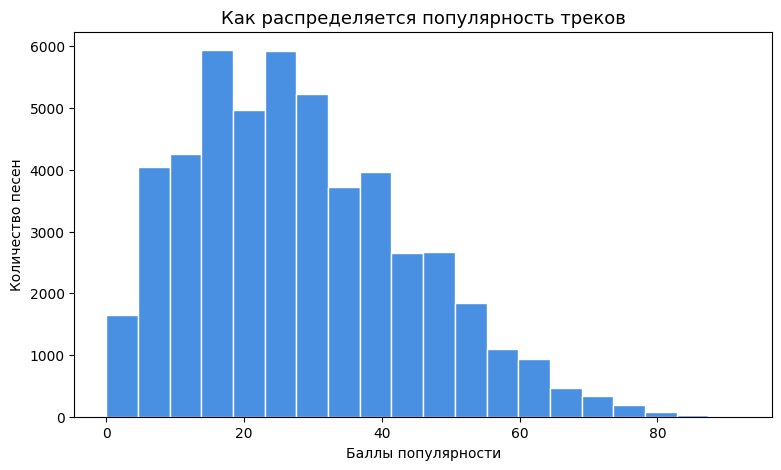

In [15]:
plt.figure(figsize=(9, 5))
plt.hist(df["popularity"], bins=20, color="#4a90e2", edgecolor="white")

plt.title("Как распределяется популярность треков", fontsize=13)
plt.xlabel("Баллы популярности")
plt.ylabel("Количество песен")
plt.show()


In [22]:
# === КОНТРОЛЬНЫЕ ВОПРОСЫ ===

# 1. Что такое DataFrame?
# Это обычная таблица с данными в Python.
# В ней есть строки и подписанные столбцы, с которыми удобно работать.

# 2. Что такое признак (Feature)?
# Это просто колонка в нашей таблице она описывает свойство объекта.
# Например, для трека признаки это жанр, год выпуска или темп.

# 3. Чем среднее арифметическое отличается от медианы?
# Среднее — это сумма всех чисел, деленная на их количество.
# Медиана — это число ровно по центру отсортированного списка.

# 4. Что показывает гистограмма?
# Она показывает форму распределения чисел: каких значений в столбце много, а каких мало.

# 5. Для чего нужна фильтрация данных?
# Чтобы отсеять ненужное и оставить только те строки, которые подходят под наше условие.


In [21]:
# === ИТОГОВЫЙ ВЫВОД ===

# В ходе работы я вспомнил базовые навыки работы с Pandas и Matplotlib в Jupyter.
# Загрузил датасет, проверил структуру табличных данных и типы колонок.
# Нашел топ-10 треков через сортировку и отфильтровал свежие релизы.
# Посчитал статистику (среднее, медиану, моду) и построил гистограмму.
# График показал, что большинство треков имеют среднюю популярность, а крайние выбросы редки.
# Задачи выполнены.
